In [136]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import (
    prandtl_number,
    reynolds_number,
    nusselt_number_dittus_boelter,
    liter_per_minute_to_kg_per_s
            )

cell_in_series = 4  # Number of cells in series

# Coolant properties
cp_water = 4186  # water [J/kg·K]
mu_water = 0.001002  # dynamic viscosity of water [Pa.s]
nu_water = mu_water / 1000  # kinematic viscosity of water [m^2/s]
k_water = 0.606  # thermal conductivity of water [W/(m.K)]
mass_flow_rate = liter_per_minute_to_kg_per_s(0.29*cell_in_series)  # flow rate [kg/s] 
volume_flow_rate = mass_flow_rate / 1000  # volume flow rate [m^3/s] (assuming water density ~1000 kg/m^3)
print(f"Flow rate: {mass_flow_rate:.5f} kg/s")

# Cross-sectional area of the coolant channel
s_channel = 1 #mm
h_channel = 50 #mm
p_channel = 2*(s_channel + h_channel) * 1e-3  # perimeter of the channel [m]
A_channel = s_channel * h_channel * 1e-6  # cross-sectional area of the channel [m^2]


Flow rate: 0.01933 kg/s


### Evaluation of Heat Transfer Coefficient (HTC)

The next cell calculates the convective heat transfer coefficient (HTC) using the following formulas:

1. **Prandtl Number ($Pr$)**  
    The Prandtl number is a dimensionless quantity that relates the momentum diffusivity to the thermal diffusivity:
    $$
    Pr = \frac{\mu \cdot c_p}{k}
    $$
    where:
    - $\mu$: Dynamic viscosity [Pa·s]
    - $c_p$: Specific heat capacity [J/kg·K]
    - $k$: Thermal conductivity [W/m·K]

2. **Reynolds Number ($Re$)**  
    The Reynolds number is a dimensionless quantity that characterizes the flow regime:
    $$
    Re = \frac{\rho \cdot v \cdot D}{\mu}
    $$
    where:
    - $\rho$: Fluid density [kg/m³]
    - $v$: Flow velocity [m/s]
    - $D$: Hydraulic diameter [m]
    - $\mu$: Dynamic viscosity [Pa·s]

3. **Nusselt Number ($Nu$)**  
    The Nusselt number is a dimensionless quantity that relates convective to conductive heat transfer:
    - For turbulent flow ($Re > 2300$), the Dittus-Boelter equation is used:
      $$
      Nu = 0.023 \cdot Re^{0.8} \cdot Pr^{n}
      \\
      n = 0.3 \text{ for heating, } n = 0.4 \text{ for cooling}
      $$
    - For laminar flow ($Re \leq 2300$), a constant value is assumed:
      $$
      Nu = 3.66
      $$

4. **Convective Heat Transfer Coefficient ($h$)**  
    The HTC is calculated using the Nusselt number:
    $$
    h = \frac{Nu \cdot k}{D}
    $$
    where:
    - $Nu$: Nusselt number
    - $k$: Thermal conductivity [W/m·K]
    - $D$: Hydraulic diameter [m]

In [137]:

# Speed of the coolant
v_coolant = volume_flow_rate / A_channel  # speed of the coolant [m/s]
D_hidraulic = 4 * A_channel / p_channel  # hydraulic diameter of the channel [m]

Pr = prandtl_number(mu_water,cp_water, k_water)
Re = reynolds_number(v_coolant,D_hidraulic,nu_water)
if Re > 2300:
    Nu = nusselt_number_dittus_boelter(Re, Pr)
else:
    Nu = 3.66  # default for fully developed laminar flow in circular tube, constant wall temp

print(f"Hydraulic diameter: {D_hidraulic:.5f} m")
print(f"Coolant speed: {v_coolant:.5f} m/s")
print(f"Prandtl number: {Pr:.2f}")
print(f"Reynolds number: {Re:.2f}")
print(f"Nusselt number: {Nu:.2f}")

#htc_analytic = ((0.68 + (0.67*Re**(1/4))) / ((1+(0.492/Pr)**(9/16))**(4/9))) * k_water / D_hidraulic
#htc_analytic = ((0.825 + (0.387*Re**(1/6))) / ((1+(0.492/Pr)**(9/16)))**(8/27)) * k_water / D_hidraulic
htc_analytic = Nu * k_water / D_hidraulic  # convective heat transfer coefficient [W/(m^2·K)]

print(f"Convective heat transfer coefficient: {htc_analytic:.2f} W/(m^2·K)")

Hydraulic diameter: 0.00196 m
Coolant speed: 0.38667 m/s
Prandtl number: 6.92
Reynolds number: 756.66
Nusselt number: 3.66
Convective heat transfer coefficient: 1131.16 W/(m^2·K)


### Model Description and Formulas

This section describes the thermal model used to simulate heat transfer and fluid dynamics within a discretized cell. The model incorporates conduction, convection, and heat generation mechanisms to predict temperature distribution and fluid temperature evolution.

#### 1. **Cell Geometry and Discretization**
The cell is modeled as a rectangular prism with dimensions:
- Length ($L$): 0.270 m
- Height ($H$): 0.106 m
- Thickness ($T$): 0.0248 m

The cell is discretized into smaller volumes:
- $n_x$: Number of elements along the $x$-direction.
- $n_y$: Number of elements along the $y$-direction.
- $n_z$: Number of elements along the $z$-direction.

The discretization results in a grid of cells, each with dimensions:
- $\Delta x = \frac{L}{n_x}$
- $\Delta y = \frac{T}{n_y}$
- $\Delta z = \frac{H}{n_z}$


The volume of each discretized cell is:
$$
dV = \frac{L}{n_x} \cdot \frac{T}{n_y} \cdot \frac{H}{n_z}
$$

#### 2. **Thermal Properties**
- **Material Properties**:
    - Thermal conductivity ($k$) in $x$, $y$, and $z$-directions.
    - Density ($\rho$) and specific heat ($c_p$) of the cell material.
- **Coolant Properties**:
    - Specific heat ($c_p$) and flow rate ($\dot{m}$) of the coolant.

#### 3. **Heat Transfer Mechanisms**
- **Conduction**:
    Heat conduction is modeled using thermal resistance:
    $$
    R_{\text{th,cond}} = \frac{\Delta x}{k \cdot \delta A}
    $$
    where $\delta A$ is the cross-sectional area perpendicular to the heat flow $\delta A = \delta_i * \delta_j$.

- **Convection**:
    Convective heat transfer is modeled using:
    $$ 
    R_{\text{th,conv}} = \frac{1}{h \cdot \delta A}
    $$
    where $h$ is the convective heat transfer coefficient.

- **Film Resistance**:
    A thin film layer introduces additional resistance:
    $$ 
    R_{\text{th,film}} = \frac{s_{\text{film}}}{k_{\text{film}} \cdot \delta A}
    $$





Flow rate: 0.01933 kg/s
Mass of each cell: 0.01 kg


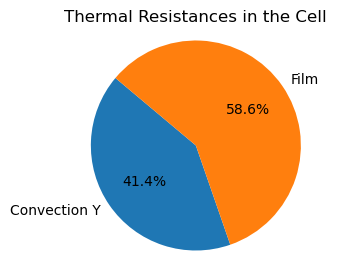

In [138]:
# --- Constants ---
length = 0.270 * cell_in_series  # cell length in x [m]
height = 0.106  # cell height in z [m]
thickness = 0.0248  # cell thickness in y [m]
s_film = 0.25e-3  # film thickness [m] (0.1 mm)
volume = length * height * thickness  # cell volume [m^3]

# Discretization parameters
nx = 10*cell_in_series # discretization in x
nz = 2  # discretization in z-->!!!!!!!!DO NOT CHANGE THIS VALUE, IT IS A 1D SIMPLIFICATION
ny = 15  # discretization in y (1D simplification, use 1 for now)
dx = length / nx
dz = height / nz
dy = thickness / ny
dV = dx * dy * dz  # volume of each cell [m^3]

# Coolant properties
cp_fluid = 4186  # water [J/kg·K]
print(f"Flow rate: {mass_flow_rate:.5f} kg/s")

# Boundary and initial conditions
T_init = 20  # Initial temperature [C]
T_fluid_in = 20  # Coolant inlet temperature [C]
h_conv = htc_analytic  # Convective heat transfer coefficient [W/m^2·K]
#h_conv = 1750

# Material properties
k_cell_x = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_z = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_y = 1.0          # thermal conductivity of cell in the plane y-z [W/m·K]
k_film = 0.2           # thermal conductivity of film [W/m·K] 

rho_cell = 2700.0    # density [kg/m^3] (Close to bulk Aluminum)
m_cell = rho_cell * dV  # mass of each cell [kg]
print(f"Mass of each cell: {m_cell:.2f} kg")
cp_cell = 1040      # specific heat [J/kg·K] (Close to bulk Aluminum)
#alpha = k_cell_x / (rho_cell * cp_cell)  # thermal conductivity [m^2/s]

Rth_cond_x = dx / (k_cell_x*dz*dy)  # thermal resistance in x direction [K/W]
Rth_cond_z = dz / (k_cell_z*dx*dy)  # thermal resistance in x direction [K/W]
Rth_cond_y = dy / (k_cell_y*dx*dz)  # thermal resistance in y direction [K/W]
Rth_conv_y = 1/(h_conv * dx * dz)  # thermal resistance in y direction [K/W]
Rth_film = s_film/(k_film * dz * dx)  # thermal resistance of film [K/W]

#Pie chart of the resistances
resistances_y = {
    'Convection Y': Rth_conv_y,
    'Film': Rth_film
}
plt.figure(figsize=(4, 3))
plt.pie(resistances_y.values(), labels=resistances_y.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Thermal Resistances in the Cell')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Temperature Update Mechanism

This section describes how the temperature of the elements and the coolant (water) is updated during the simulation. The updates are based on heat transfer mechanisms and material properties.

#### 1. **Element Temperature Update**
The temperature of each element is updated iteratively using the net heat transfer and the material properties of the element. The formula used is:

- **Temperature Change**:  
    $$
    \Delta T_{\text{element}} = \frac{Q_{\text{net}} \cdot \Delta t}{m_{\text{element}} \cdot c_{p,\text{element}}}
    $$

Here:
- $Q_{\text{net}}$: Net heat transfer for the element, calculated as the sum of conduction, convection, and heat generation.
- $\Delta t$: Time step for the simulation.
- $m_{\text{element}}$: Mass of the element, calculated as $\rho_{\text{element}} \cdot dV$.
- $c_{p,\text{element}}$: Specific heat capacity of the element material.

The updated temperature is then:
$$
T_{\text{element,new}} = T_{\text{element,old}} + \Delta T_{\text{element}}
$$

#### 2. **Coolant (Water) Temperature Update**
The coolant temperature is updated based on the heat transferred from the element to the fluid via convection. The formula used is:

- **Fluid Temperature Change**:  
    $$
    \Delta T_{\text{fluid}} = \frac{Q_{\text{conv}}}{\dot{m} \cdot c_{p,\text{fluid}}}
    $$

Here:
- $Q_{\text{conv}}$: Heat transferred via convection, calculated as:
    $$
    Q_{\text{conv}} = \frac{T_{\text{element}} - T_{\text{fluid}}}{R_{\text{th,conv,y}} + R_{\text{th,film}}}
    $$
- $\dot{m}$: Mass flow rate of the coolant.
- $c_{p,\text{fluid}}$: Specific heat capacity of the coolant.

The next fluid element temprature is then updated as:
$$
T_{\text{fluid,next}} = T_{\text{fluid}} + \Delta T_{\text{fluid}}
$$

#### 3. **Heat Exchange Between Elements**
Heat conduction between neighboring elements is modeled using the thermal resistance in each direction ($x$, $y$, and $z$). The heat transfer between two adjacent elements is calculated as:

- **Conduction Heat Transfer**:  
    $$
    Q_{\text{cond}} = \frac{\Delta T}{R_{\text{th,cond}}}
    $$

Here:
- $\Delta T$: Temperature difference between adjacent elements.
- $R_{\text{th,cond}}$: Thermal resistance in the respective direction, calculated as:
    $$
    R_{\text{th,cond,x}} = \frac{\Delta x}{k_{\text{element,x}} \cdot \delta A}, \quad R_{\text{th,cond,y}} = \frac{\Delta y}{k_{\text{element,y}} \cdot \delta A}, \quad R_{\text{th,cond,z}} = \frac{\Delta z}{k_{\text{element,z}} \cdot \delta A}
    $$

The net heat transfer for each element is the sum of conduction heat transfer from all neighboring elements, convection heat transfer, and internal heat generation. These updates are performed iteratively for each time step to simulate the dynamic thermal behavior of the system.


In [139]:
# Time setup
dt = 1  # time step [s]
t_end = 4500  # total time [s]
nt = int(t_end / dt)


Q_tot = 60 * cell_in_series # Total heat generation [W]
q_gen = Q_tot/volume # Heat generation [W/m^3]

# Cross-sectional area for convection (1D simplification)
A_conv = dz * dx  # 1m depth assumed

# --- Initialize temperature field ---
T = np.ones([nx, ny, nz]) * T_init
# --- Functions ---

def convection_loss(T_cell, T_fluid):
    q_conv = (T_cell - T_fluid)/(Rth_conv_y + Rth_film)
    return  q_conv


def update_fluid_temp(T_fluid, q_conv, mass_flow_rate, cp_fluid):
    # m_dot * cp * dT = q_conv  => dT = q_conv / (m_dot * cp)
    m_dot = mass_flow_rate  # [kg/s]
    dT_fluid = q_conv / (m_dot * cp_fluid)

    return T_fluid + dT_fluid


# --- Temperature Field Initialization ---
T = np.ones((nx, ny, nz)) * T_init  # 3D temperature grid
T_hist = np.zeros((nt, nx, ny, nz))  # Temperature history

# --- Fluid Temperature Tracking (z = 0 forward, z = 1 backward)
T_fluid_z0 = np.ones(nx) * T_fluid_in
T_fluid_z1 = np.ones(nx) * T_fluid_in
t_hist_fluid_z0 = np.zeros((nt, nx))
t_hist_fluid_z1 = np.zeros((nt, nx))


# --- Time Loop ---
for t in range(nt):
    T_new = T.copy()
    Q_cond = np.zeros_like(T)

    # --- Conduction: X Direction ---
    for i in range(nx - 1):
        for j in range(ny):
            for k in range(nz):
                dT = T[i + 1, j, k] - T[i, j, k]
                if cell_in_series != 1 and i + 1 == nx/cell_in_series:
                    dT = 0  # No conduction to the second layer
                    #print(f"Skipping conduction for last cell in first layer at i={i}, j={j}, k={k}")
                    
                q = dT / Rth_cond_x
                Q_cond[i, j, k] += q
                Q_cond[i + 1, j, k] -= q


    # --- Conduction: Y Direction ---
    for j in range(ny - 1):
        for i in range(nx):
            for k in range(nz):
                dT = T[i, j + 1, k] - T[i, j, k]
                q = dT / Rth_cond_y
                Q_cond[i, j, k] += q
                Q_cond[i, j + 1, k] -= q

    # --- Conduction: Z Direction ---
    for k in range(nz - 1):
        for i in range(nx):
            for j in range(ny):
                dT = T[i, j, k + 1] - T[i, j, k]
                q = dT / Rth_cond_z
                Q_cond[i, j, k] += q
                Q_cond[i, j, k + 1] -= q

    # --- Layer z = 0: Forward fluid flow (left to right)
    for i in range(nx):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:  # Convection on y = 0
                conv_therm = convection_loss(T[i, j, 0], T_fluid_z0[i])
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 0]
                if i < nx - 1: #update fluid temperature only if not at the last cell and only for the first layer (cooled side)
                    T_fluid_z0[i + 1] = update_fluid_temp(T_fluid_z0[i], conv_therm, mass_flow_rate, cp_fluid)
            else:  # No convection, intenral layer
                Q_net = Q_gen_cell + Q_cond[i, j, 0]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 0] += dT

    # --- U-turn: Connect fluid from z=0 to z=1
    T_fluid_z1[-1] = T_fluid_z0[-1]

    # --- Layer z = 1: Backward fluid flow (right to left)
    for i in reversed(range(nx)):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:
                conv_therm = convection_loss(T[i, j, 1], T_fluid_z1[i])
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 1]
                if i > 0:
                    T_fluid_z1[i - 1] = update_fluid_temp(T_fluid_z1[i], conv_therm, mass_flow_rate, cp_fluid)
            else:
                Q_net = Q_gen_cell + Q_cond[i, j, 1]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 1] += dT

    # --- Save history ---
    T = T_new.copy()
    T_hist[t] = T
    t_hist_fluid_z0[t] = T_fluid_z0.copy()
    t_hist_fluid_z1[t] = T_fluid_z1.copy()

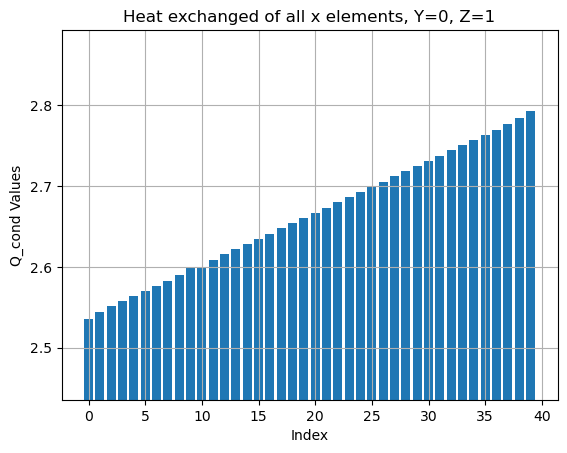

In [140]:
bar_values = Q_cond[:, 0, 1]  # Extract the values for the bar chart
x_coords = np.arange(len(bar_values))  # Generate x-coordinates based on the length of bar_values
plt.bar(x_coords, bar_values)  # Plot the bar chart with matching shapes
plt.xlabel("Index")
plt.ylabel("Q_cond Values")
plt.title("Heat exchanged of all x elements, Y=0, Z=1")
plt.ylim(bar_values.min() - 0.1, bar_values.max() + 0.1)
plt.grid(True)
plt.show()

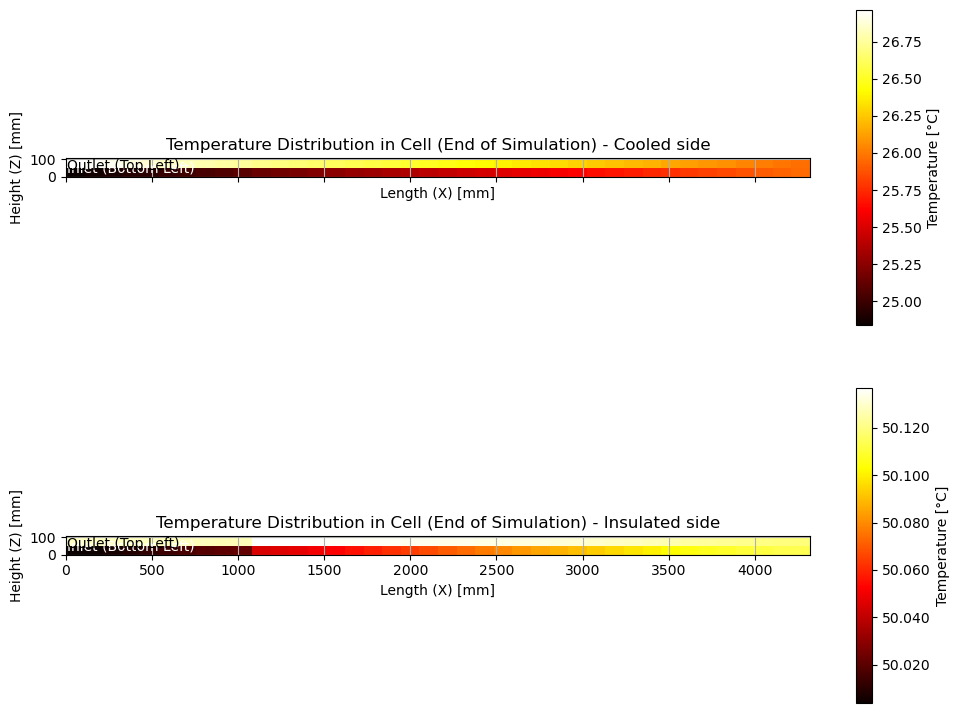

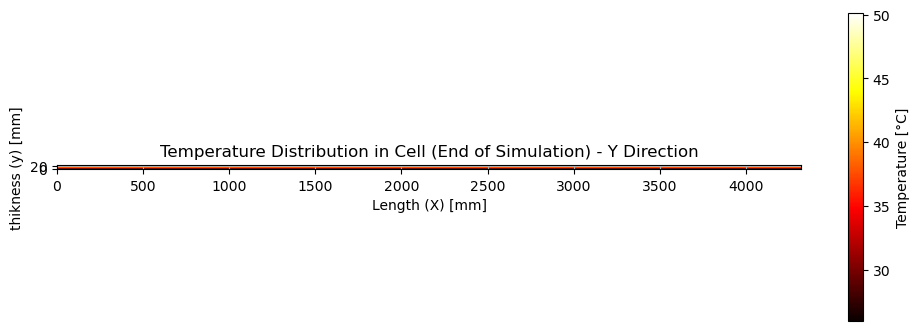

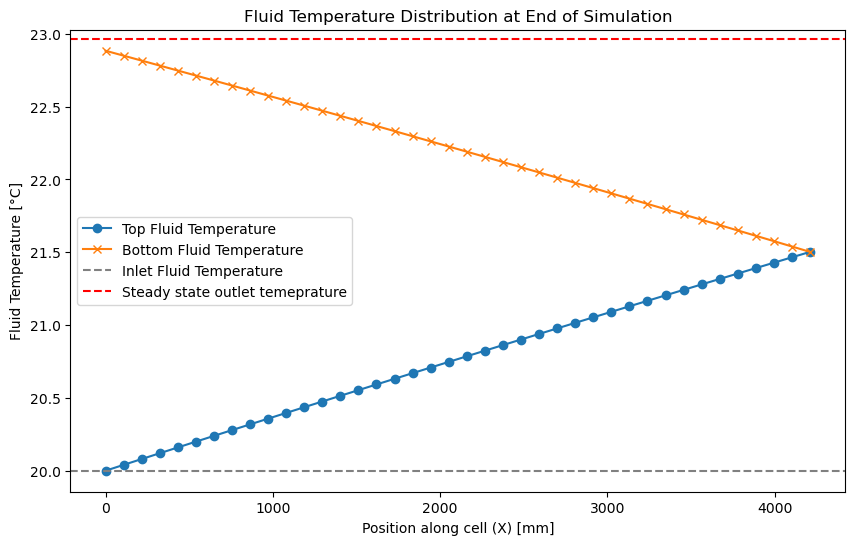

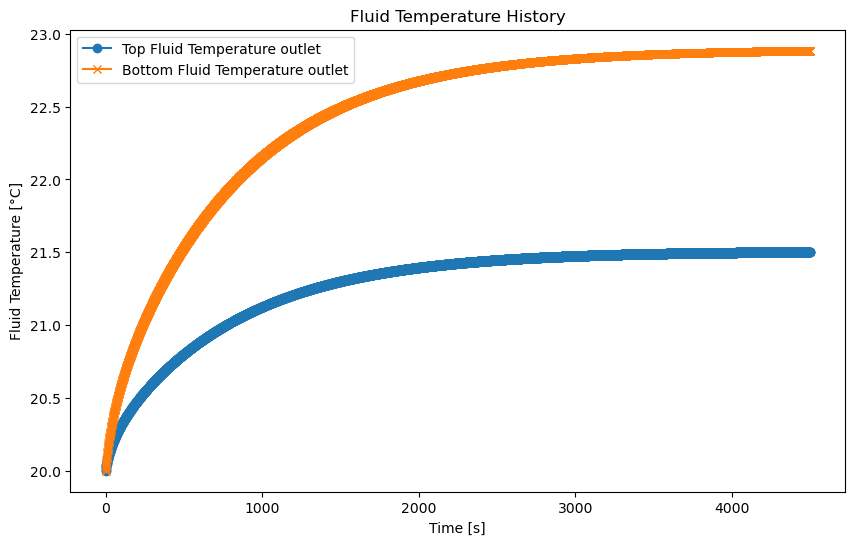

50.136745022159936

In [142]:
# --- Plot result ---
fig, ax = plt.subplots(2,1, figsize=(12, 9), sharex=True, sharey=True)
extent = [0, length*1000 * cell_in_series, 0, height*1000]
ax[0].imshow(T[:, 0, :].T, cmap="hot", origin="lower", extent=extent)
plt.colorbar(ax[0].imshow(T[:, 0, :].T, cmap="hot", origin="lower", extent=extent), ax=ax[0], label="Temperature [°C]")
ax[0].set_xlabel("Length (X) [mm]")
ax[0].set_ylabel("Height (Z) [mm]")
ax[0].set_title("Temperature Distribution in Cell (End of Simulation) - Cooled side")
ax[0].grid(True)
#annotate inlet and outlet
ax[0].text(5, 5, "Inlet (Bottom Left)", color="white", fontsize=10, ha="left", va="bottom")
ax[0].text(5, height*1000 - 5, "Outlet (Top Left)", color="black", fontsize=10, ha="left", va="top")


ax[1].imshow(T[:, ny-1, :].T, cmap="hot", origin="lower", extent=extent)
plt.colorbar(ax[1].imshow(T[:, ny-1, :].T, cmap="hot", origin="lower", extent=extent), ax=ax[1], label="Temperature [°C]", format="%.3f")  
ax[1].set_xlabel("Length (X) [mm]")
ax[1].set_ylabel("Height (Z) [mm]")
ax[1].set_title("Temperature Distribution in Cell (End of Simulation) - Insulated side")
ax[1].grid(True)
#annotate inlet and outlet
ax[1].text(5, 5, "Inlet (Bottom Left)", color="white", fontsize=10, ha="left", va="bottom")
ax[1].text(5, height*1000 - 5, "Outlet (Top Left)", color="black", fontsize=10, ha="left", va="top")



# Plot also the temperature in the y direction
plt.figure(figsize=(12, 4))
extent = [0, length*1000 * cell_in_series, 0, thickness*1000]
plt.imshow(T[:, :, 1].transpose(), cmap="hot", origin="lower", extent=tuple(extent))
plt.colorbar(label="Temperature [°C]")
plt.xlabel("Length (X) [mm]")
plt.ylabel("thikness (y) [mm]")
plt.title("Temperature Distribution in Cell (End of Simulation) - Y Direction")
plt.grid(True)


# Plot the water temperature at the end of the simulation
plt.figure(figsize=(10, 6))
plt.plot(np.arange(nx) * dx * 1000 * cell_in_series , T_fluid_z0, label="Top Fluid Temperature", marker='o')
plt.plot(np.arange(nx) * dx * 1000 * cell_in_series, T_fluid_z1, label="Bottom Fluid Temperature", marker='x')
plt.axhline(y=T_fluid_in, color='gray', linestyle='--', label="Inlet Fluid Temperature")
plt.axhline(y = T_fluid_in+Q_tot/(mass_flow_rate * cp_fluid), color='red', linestyle='--', label="Steady state outlet temeprature")
plt.xlabel("Position along cell (X) [mm]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature Distribution at End of Simulation")
plt.legend()

#Plot the fluid temperature history
plt.figure(figsize=(10, 6))
plt.plot(np.arange(nt) * dt, t_hist_fluid_z0[:, -1], label="Top Fluid Temperature outlet", marker='o')
plt.plot(np.arange(nt) * dt, t_hist_fluid_z1[:, 0], label="Bottom Fluid Temperature outlet", marker='x')
plt.xlabel("Time [s]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature History")
plt.legend()
plt.show()

np.max(T[:, ny-1, :].T)

### Steady-State Check for Simulation Accuracy

The code checks the correctness of the simulation at steady state by calculating key thermal parameters and comparing them. Below are the steps and formulas used:

1. **Thermal Resistance of the Film**  
    The thermal resistance of the film is calculated using the formula:  
    $$
    R_{\text{th,film,cell}} = \frac{s_{\text{film}}}{k_{\text{film}} \cdot \text{height} \cdot \text{length}}
    $$

2. **Convective Thermal Resistance**  
    The convective thermal resistance is calculated as:  
    $$
    R_{\text{th,convective,cell}} = \frac{1}{h_{\text{conv}} \cdot \text{height} \cdot \text{length}}
    $$

3. **Total Thermal Resistance**  
    The total thermal resistance is the sum of the film and convective resistances:  
    $$
    R_{\text{th,total}} = R_{\text{th,film,cell}} + R_{\text{th,convective,cell}}
    $$

4. **Temperature Difference Between Fluid and Cell**  
    The temperature difference between the fluid and the cell is calculated using:  
    $$
    \Delta T_{\text{Fluid,Cell}} = Q_{\text{tot}} \cdot R_{\text{th,total}}
    $$

5. **Temperature Difference in the Fluid**  
    The temperature difference in the fluid is computed as:  
    $$
    \Delta T_{\text{Fluid}} = \frac{Q_{\text{tot}}}{\dot{m} \cdot c_p}
    $$  
    where $(\dot{m})$ is the mass flow rate and $(c_p)$ is the specific heat capacity of the fluid.

6. **Mean Fluid Temperature**  
    The mean fluid temperature is calculated as:  
    $$
    T_{\text{mean,fluid}} = T_{\text{fluid,in}} + \frac{\Delta T_{\text{Fluid}}}{2}
    $$

7. **Cooled Cell Surface Temperature**  
    The cooled cell surface temperature is determined using:  
    $$
    T_{\text{cooled,surface}} = T_{\text{mean,fluid}} + \Delta T_{\text{Fluid,Cell}}
    $$

8. **Insulated Cell Surface Temperature**  
    The temperature along the cell in the $(y)$-direction is calculated using a linear distribution:  
    $$
    T_x = T_{\text{cooled,surface}} + \frac{q_{\text{spec}}}{k_{\text{cell}}} \left( \frac{\text{thick}^2}{2} - \frac{x^2}{2} \right)
    $$  
    At $(x = 0)$, the insulated cell surface temperature is:  
    $$
    T_{\text{insulated,surface}} = T_{\text{cooled,surface}} + \frac{q_{\text{spec}}}{k_{\text{cell}}} \cdot \frac{\text{thick}^2}{2}
    $$  

These formulas ensure the simulation results align with theoretical steady-state conditions.

Total thermal resistance of the cell: 0.0186 K/W
Temperature difference between fluid and cell: 4.47 °C
Temperature difference in the fluid: 2.97 °C
Mean fluid temperature: 21.48 °C
Cooled cell surface temperature: 25.96 °C


Eq(T_x, T_cooled_surface + q_spec*(thick**2/2 - x**2/2)/k_cell)

Insulated cell surface temperature: 51.95 °C
Discrete y positions: [ 0.          1.65333333  3.30666667  4.96        6.61333333  8.26666667
  9.92       11.57333333 13.22666667 14.88       16.53333333 18.18666667
 19.84       21.49333333 23.14666667]
Discrete temperatures: [26.96384562 29.95787211 32.77131947 35.39329104 37.81534372 40.03093206
 42.03498335 43.82357129 45.39366505 46.74293622 47.8696106  48.77235534
 49.45019401 49.9024442  50.12867394]


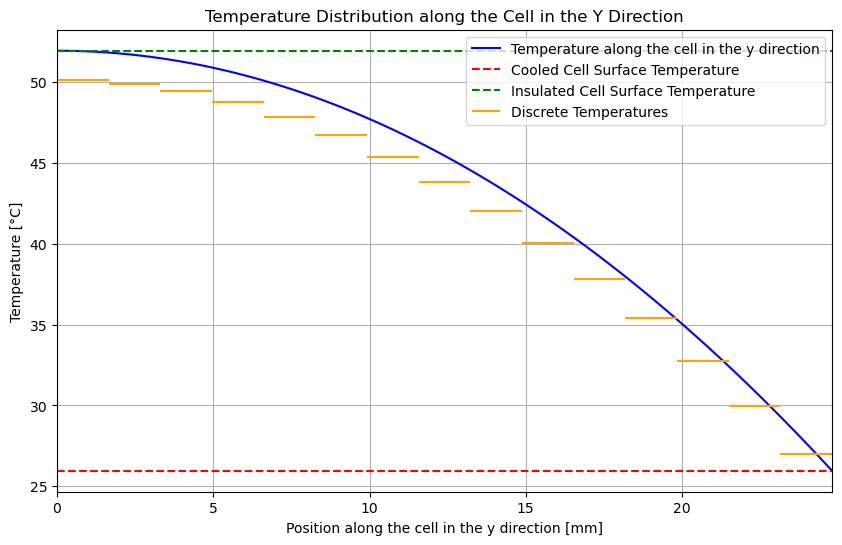

In [143]:
from sympy import symbols, Eq

# Add a check for steady state, to be sure the model is converged
Rth_film_cell = s_film/(k_film * height * length)  # thermal resistance of film [K/W]
Rth_convective_cell = 1/(h_conv * height * length)  # thermal resistance of convection [K/W]
Rth_total = Rth_film_cell + Rth_convective_cell  # total thermal resistance of the cell [K/W]
print(f"Total thermal resistance of the cell: {Rth_total:.4f} K/W")

DeltaT_Fluid_Cell = Q_tot * Rth_total  # Temperature difference in the fluid cell
print(f"Temperature difference between fluid and cell: {DeltaT_Fluid_Cell:.2f} °C")

DeltaT_Fluid = Q_tot/(mass_flow_rate * cp_fluid)  # Temperature difference in the fluid
print(f"Temperature difference in the fluid: {DeltaT_Fluid:.2f} °C")

mean_fluid_temp = T_fluid_in + DeltaT_Fluid/2  # Mean fluid temperature
print(f"Mean fluid temperature: {mean_fluid_temp:.2f} °C")

cooled_cell_surface_temp = mean_fluid_temp + DeltaT_Fluid_Cell  # Cooled cell surface temperature
print(f"Cooled cell surface temperature: {cooled_cell_surface_temp:.2f} °C")

# temeprature along the cell in the y direction
def y_direction_temperature(x, T_cooled_surface, thick, specific_heat, k_cell):
    """
    Calculate the temperature along the cell in the y direction.
    :param x: position along the cell in the x direction [m]
    :return: temperature at position x in the y direction [C]
    """
    if x < 0 or x > length:
        raise ValueError("x must be between 0 and length of the cell")
    
    # Calculate temperature based on linear distribution
    return  specific_heat/k_cell * (-(x**2)/2 + ((thick**2)/2)) + T_cooled_surface

# Define symbolic variables
x, thick, q_spec, k_cell, T_cooled_surface, T_x = symbols('x thick q_spec k_cell T_cooled_surface T_x')

# Define the equation symbolically
temperature_equation = Eq(T_x,q_spec / k_cell * ((-x**2) / 2 + (thick**2 / 2)) + T_cooled_surface)

# Display the equation
display(temperature_equation)

insulated_cell_surface_temp = y_direction_temperature(0, cooled_cell_surface_temp, thickness, q_gen, k_cell_y)
print(f"Insulated cell surface temperature: {insulated_cell_surface_temp:.2f} °C")

# Plot temperature along the cell in the y direction
x_values = np.linspace(0, thickness, 100)
y_temperatures = [y_direction_temperature(x, cooled_cell_surface_temp, thickness, q_gen, k_cell_y) for x in x_values]
plt.figure(figsize=(10, 6))
plt.plot(x_values * 1000, y_temperatures, label="Temperature along the cell in the y direction", color='blue')
plt.axhline(y=cooled_cell_surface_temp, color='red', linestyle='--', label="Cooled Cell Surface Temperature")
plt.axhline(y=insulated_cell_surface_temp, color='green', linestyle='--', label="Insulated Cell Surface Temperature")
plt.xlabel("Position along the cell in the y direction [mm]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature Distribution along the Cell in the Y Direction")

# Overlay discrete temperature points on the same plot
discrete_y_positions = np.arange(ny) * dy * 1000  # Convert to mm
print(f"Discrete y positions: {discrete_y_positions}")
discrete_temperatures = T[0, :, 1]  # Extract temperatures along the y-direction at x=0, z=1
print(f"Discrete temperatures: {discrete_temperatures}")
for i, temp in enumerate(discrete_temperatures[::-1]):
    plt.hlines(temp, discrete_y_positions[i]  , discrete_y_positions[i] + dy * 1000 , colors='orange', label="Discrete Temperatures" if i == 0 else "")
plt.xlim(0, thickness * 1000)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [134]:
# Distribution of temperature in 
print(f"Element in x direction:{nx}")
print(f"Element in y direction:{ny}")
print(f"Element in z direction:{nz}")
T[:,4,:]

Element in x direction:20
Element in y direction:15
Element in z direction:2


array([[37.00050465, 37.76735677],
       [37.01393129, 37.75752213],
       [37.03399674, 37.74305789],
       [37.0567504 , 37.72679973],
       [37.08044318, 37.70984832],
       [37.10425732, 37.69261299],
       [37.12762914, 37.67534748],
       [37.14979439, 37.65851453],
       [37.16913851, 37.64334786],
       [37.18198811, 37.63295376],
       [37.24856486, 37.59551298],
       [37.26094564, 37.58463902],
       [37.27932166, 37.56849254],
       [37.30003347, 37.55019801],
       [37.32150972, 37.53103327],
       [37.34305509, 37.51152999],
       [37.36421276, 37.49204879],
       [37.38434087, 37.47317479],
       [37.40200208, 37.45631938],
       [37.4138119 , 37.44487991]])

In [135]:
#%matplotlib notebook
import matplotlib.animation as animation
animation_flag = 0  # Set to 1 to enable animation, 0 to disable
if animation_flag == 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    extent = [0, length * 1000, 0, height * 1000]  # For consistent mm scale
    im = ax.imshow(T_hist[0], cmap="hot", origin="lower", extent=extent, vmin=np.min(T_hist), vmax=np.max(T_hist))
    cbar = plt.colorbar(im, ax=ax, label="Temperature [°C]")
    ax.set_xlabel("Length (X) [mm]")
    ax.set_ylabel("Height (Z) [mm]")
    ax.set_title("Temperature Evolution in Cell")
    ax.grid(True)

    def update(frame):
        im.set_array(T_hist[frame])
        ax.set_title(f"Time: {frame*dt:.1f} s")
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=nt, interval=30, blit=True)
    ani.save("temperature_evolution.mp4", writer="ffmpeg", fps=30)